# Model Evaluation

In [24]:
import importlib
import pandas as pd
import Config.constants as constants
from Config import model_configs
import pytorch_lightning as pl
from src.preprocessing.GTSRBDataset import GTSRBDataset
from src.preprocessing.transformations import get_transforms
from src.models.experiment_manager import get_experiment_setup
from torch.utils.data import DataLoader
from src.models.model_template import TrafficSignClassifier
import torch
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from matplotlib import pyplot as plt

importlib.reload(constants)

<module 'Config.constants' from 'F:\\Software\\Dataspell\\TrafficSigns\\Config\\constants.py'>

## Load Model

In [2]:
cfg_name = "exp005"

ckpt_path = constants.MODEL_CHECKPOINT

In [7]:
cfg = model_configs.CONFIGS[cfg_name]

IMAGE_SIZE = cfg["image_size"]
BATCH_SIZE = cfg["batch_size"]
lr = cfg["lr"]

experiment_setup = get_experiment_setup(cfg, num_classes=constants.NUM_CLASSES)

model_template = experiment_setup["model"]
optimizer = experiment_setup["optimizer"]
criterion = experiment_setup["criterion"]
config = experiment_setup["cfg"]

trafficSignClassifier = TrafficSignClassifier.load_from_checkpoint(
    ckpt_path,
    num_classes=constants.NUM_CLASSES,
    model=model_template,
    optimizer=optimizer,
    criterion=criterion,
)

F:\Software\Dataspell\TrafficSigns\venv\lib\site-packages\pytorch_lightning\utilities\parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
F:\Software\Dataspell\TrafficSigns\venv\lib\site-packages\pytorch_lightning\utilities\parsing.py:208: Attribute 'criterion' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['criterion'])`.


## Load Testing Data

In [4]:
test_df = pd.read_csv(constants.TEST_CSV_PATH)

test_ds = GTSRBDataset(test_df, transform=get_transforms(IMAGE_SIZE, train=False))

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

## Run Tests

In [5]:
trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    check_val_every_n_epoch=1,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [9]:
test_results = trainer.test(trafficSignClassifier, dataloaders=test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
F:\Software\Dataspell\TrafficSigns\venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:424: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9798449873924255
        test_loss           0.07707490026950836
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


## Confusion Matrix

In [11]:
preds = trainer.predict(model, dataloaders=test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
F:\Software\Dataspell\TrafficSigns\venv\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:424: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

In [21]:
y_pred = torch.cat(preds, dim=0)
y_true = torch.tensor(test_df['ClassId'].values)

In [23]:
cm = confusion_matrix(y_true, y_pred)

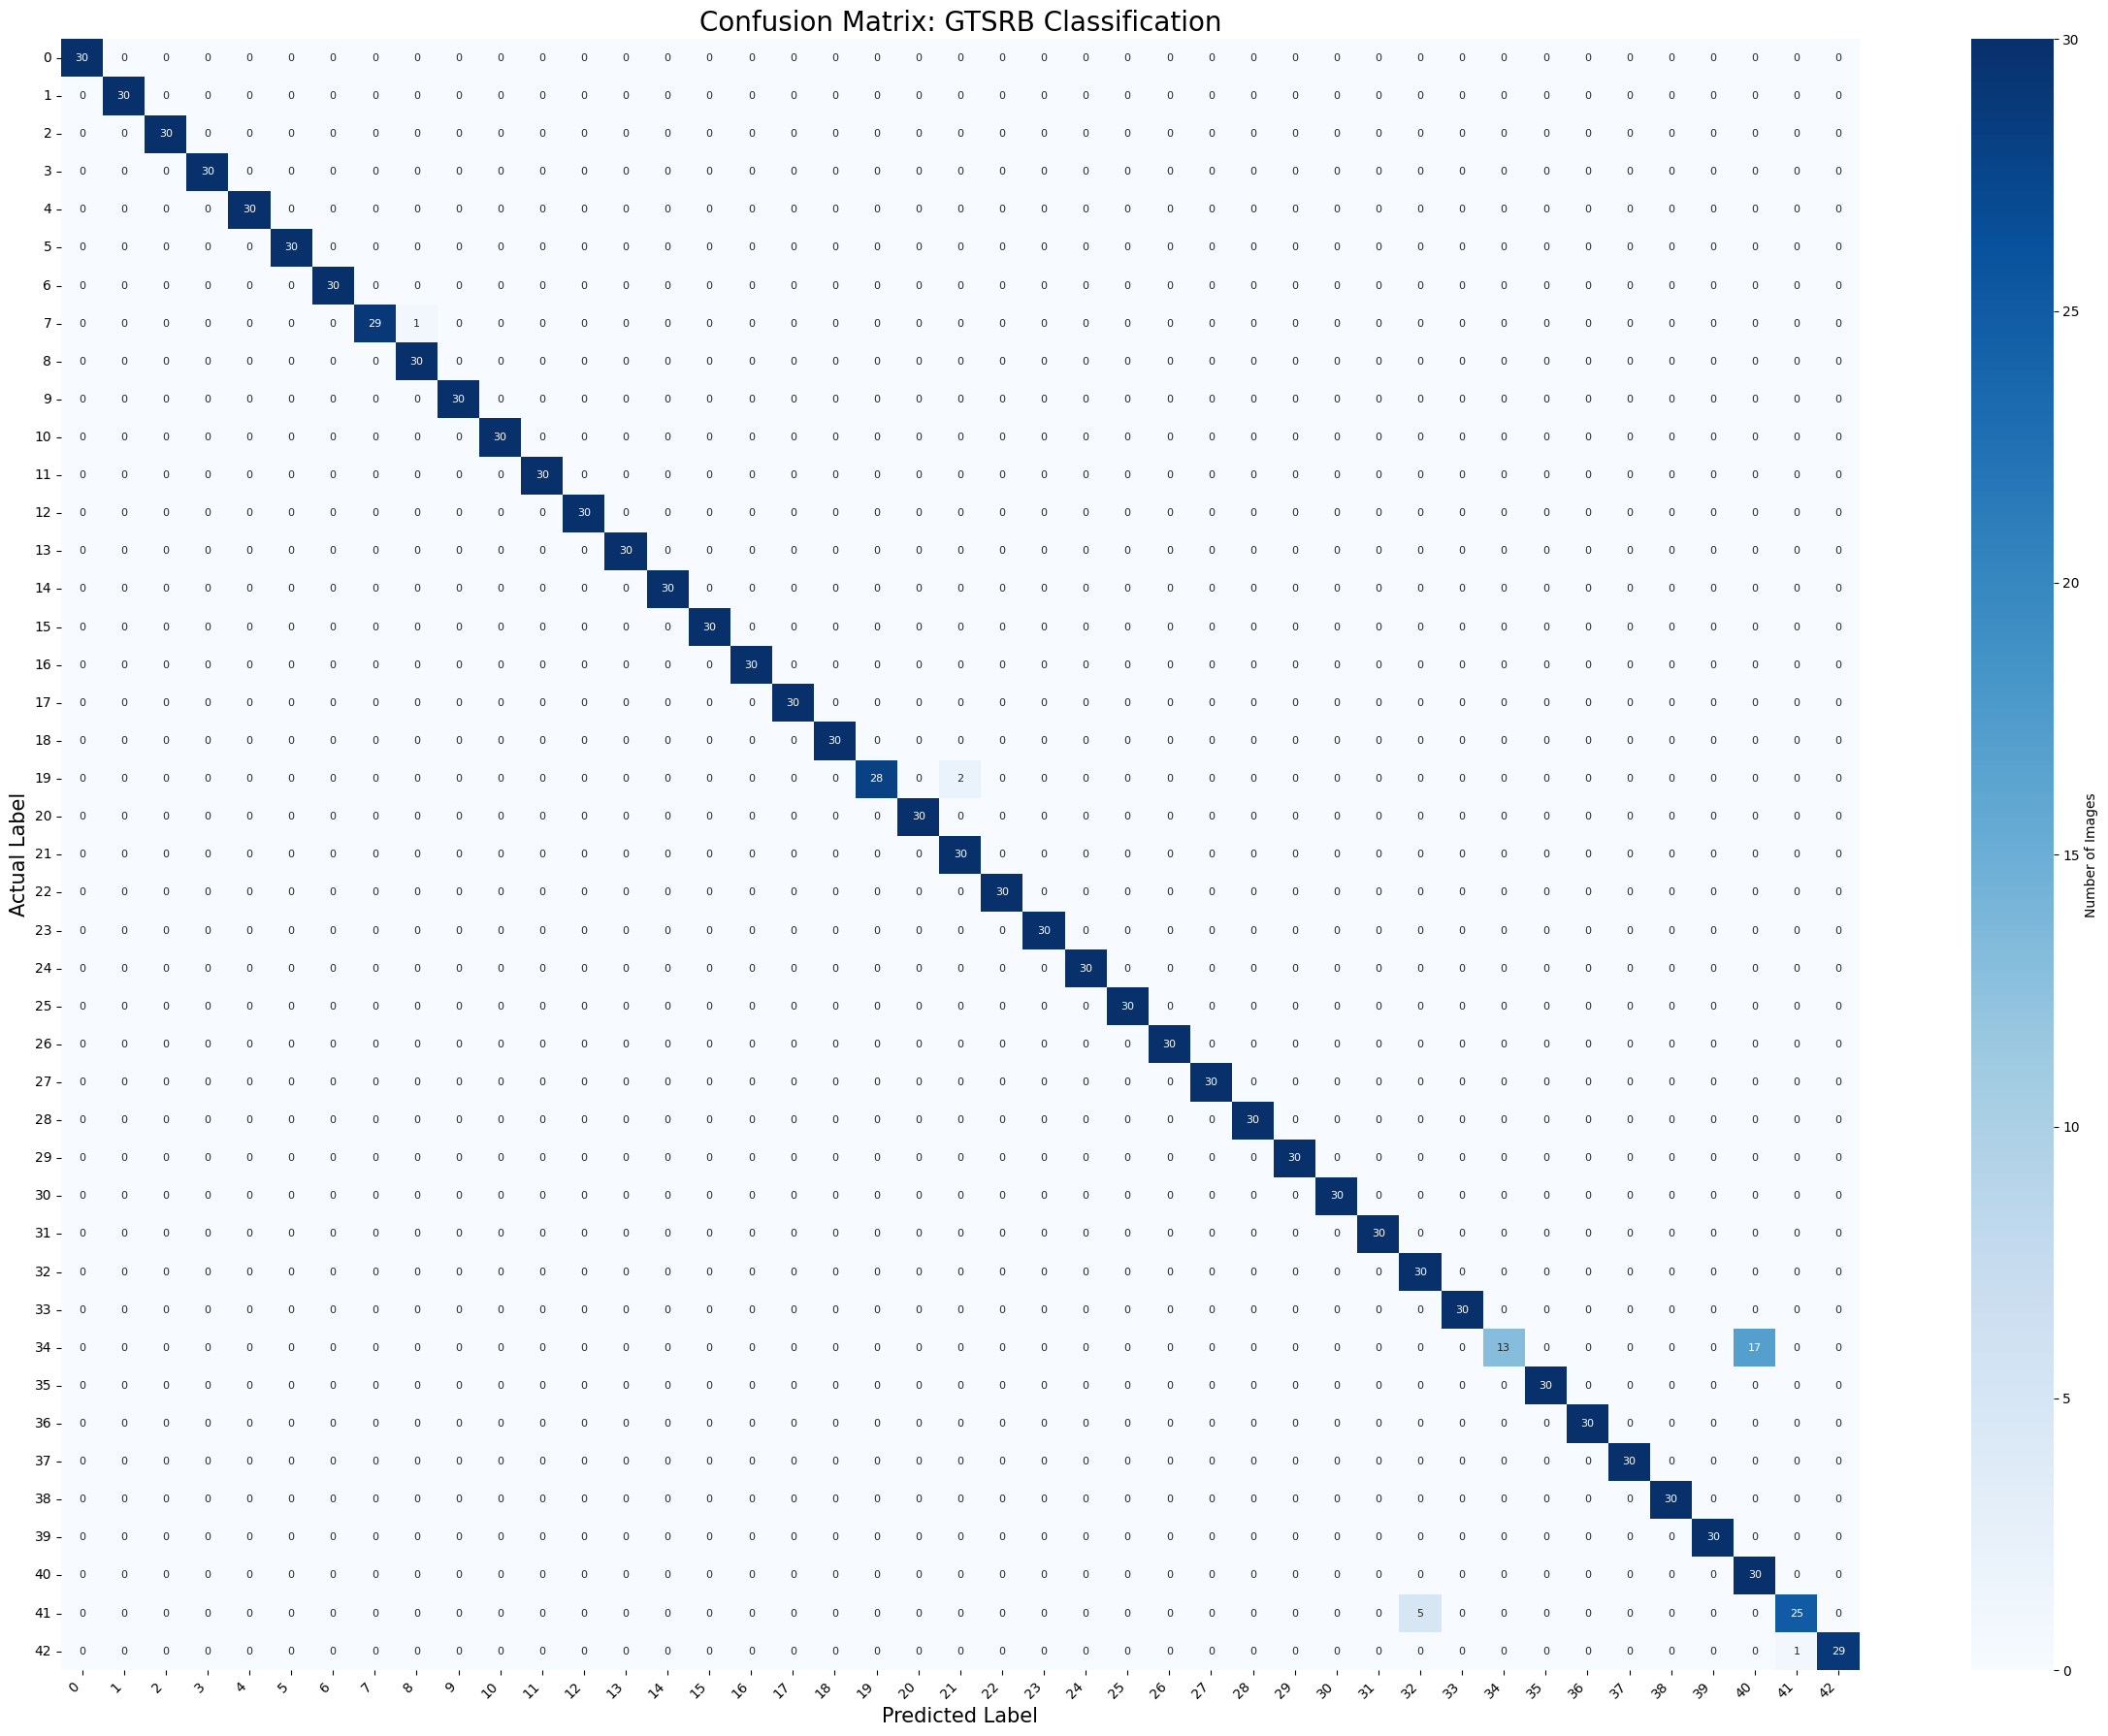

In [26]:
plt.figure(figsize=(24, 18))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar_kws={'label': 'Number of Images'},
    annot_kws={"size": 8}
)

plt.title('Confusion Matrix: GTSRB Classification', fontsize=20)
plt.ylabel('Actual Label', fontsize=15)
plt.xlabel('Predicted Label', fontsize=15)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Classification Report

In [27]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        30
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        30
           3       1.00      1.00      1.00        30
           4       1.00      1.00      1.00        30
           5       1.00      1.00      1.00        30
           6       1.00      1.00      1.00        30
           7       1.00      0.97      0.98        30
           8       0.97      1.00      0.98        30
           9       1.00      1.00      1.00        30
          10       1.00      1.00      1.00        30
          11       1.00      1.00      1.00        30
          12       1.00      1.00      1.00        30
          13       1.00      1.00      1.00        30
          14       1.00      1.00      1.00        30
          15       1.00      1.00      1.00        30
          16       1.00      1.00      1.00        30
          17       1.00    